# 🌍 Impact of War: India's Economic Analysis (2005-2026)
**Goal:** Quantify the "Shock" of global conflict on India's GDP, Inflation, and Market Stability.

### 🛠️ Methodology:
* **Markets:** Gold, Oil, Gas, S&P 500, VIX, and USD/INR.
* **Macro:** India's GDP Growth and Inflation Rate.
* **Tech:** Python, DuckDB, and Time-Series Analysis.


In [21]:
import yfinance as yf
import duckdb

# ==============================================================================
# 1. CLEAN FLATTENED DOWNLOADING LOOP
# ==============================================================================
assets = {
    "Gold": "GC=F", 
    "Oil": "CL=F", 
    "SP500": "^GSPC", 
    "VIX": "^VIX", 
    "USDINR": "INR=X", 
    "GAS": "NG=F"
}

print("📥 Fetching and flattening GitHub asset files...")
for name, symbol in assets.items():
    df_raw = yf.download(symbol, start="2005-01-01")
    
    # Your header solution: strips secondary row index layers
    df_raw.columns = df_raw.columns.get_level_values(0) 
    
    df_raw.to_csv(f"{name}.csv")

# =============
# 2.DUCKDB SQL  
# =============
con = duckdb.connect()

sql_script = """
SELECT
    COALESCE(g.Date, o.Date, s.Date, v.Date, u.Date, ga.Date) AS Date,
    g.Close AS Gold,
    o.Close AS Oil,
    s.Close AS SP500,
    v.Close AS VIX,
    u.Close AS USDINR,
    ga.Close AS GAS
FROM read_csv_auto('Gold.csv') AS g
FULL JOIN read_csv_auto('Oil.csv') AS o ON g.Date = o.Date
FULL JOIN read_csv_auto('SP500.csv') AS s ON g.Date = s.Date
FULL JOIN read_csv_auto('VIX.csv') AS v ON g.Date = v.Date
FULL JOIN read_csv_auto('USDINR.csv') AS u ON g.Date = u.Date
FULL JOIN read_csv_auto('GAS.csv') AS ga ON g.Date = ga.Date
ORDER BY Date ASC
"""

df = con.execute(sql_script).fetchdf()

df = df.ffill().bfill()



📥 Fetching and flattening GitHub asset files...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



✨ GitHub Aligned Master Dataframe Constructed:
        Date        Gold        Oil        SP500    VIX     USDINR    GAS
0 2005-01-03  428.700012  42.119999  1202.079956  14.08  43.416000  5.790
1 2005-01-04  428.500000  43.910000  1188.050049  13.98  43.491001  5.902
2 2005-01-05  426.600006  43.389999  1183.739990  14.09  43.589001  5.833
3 2005-01-06  421.000000  45.560001  1187.890015  13.58  43.827999  6.049
4 2005-01-07  418.899994  45.430000  1186.189941  13.49  43.832001  6.001


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns


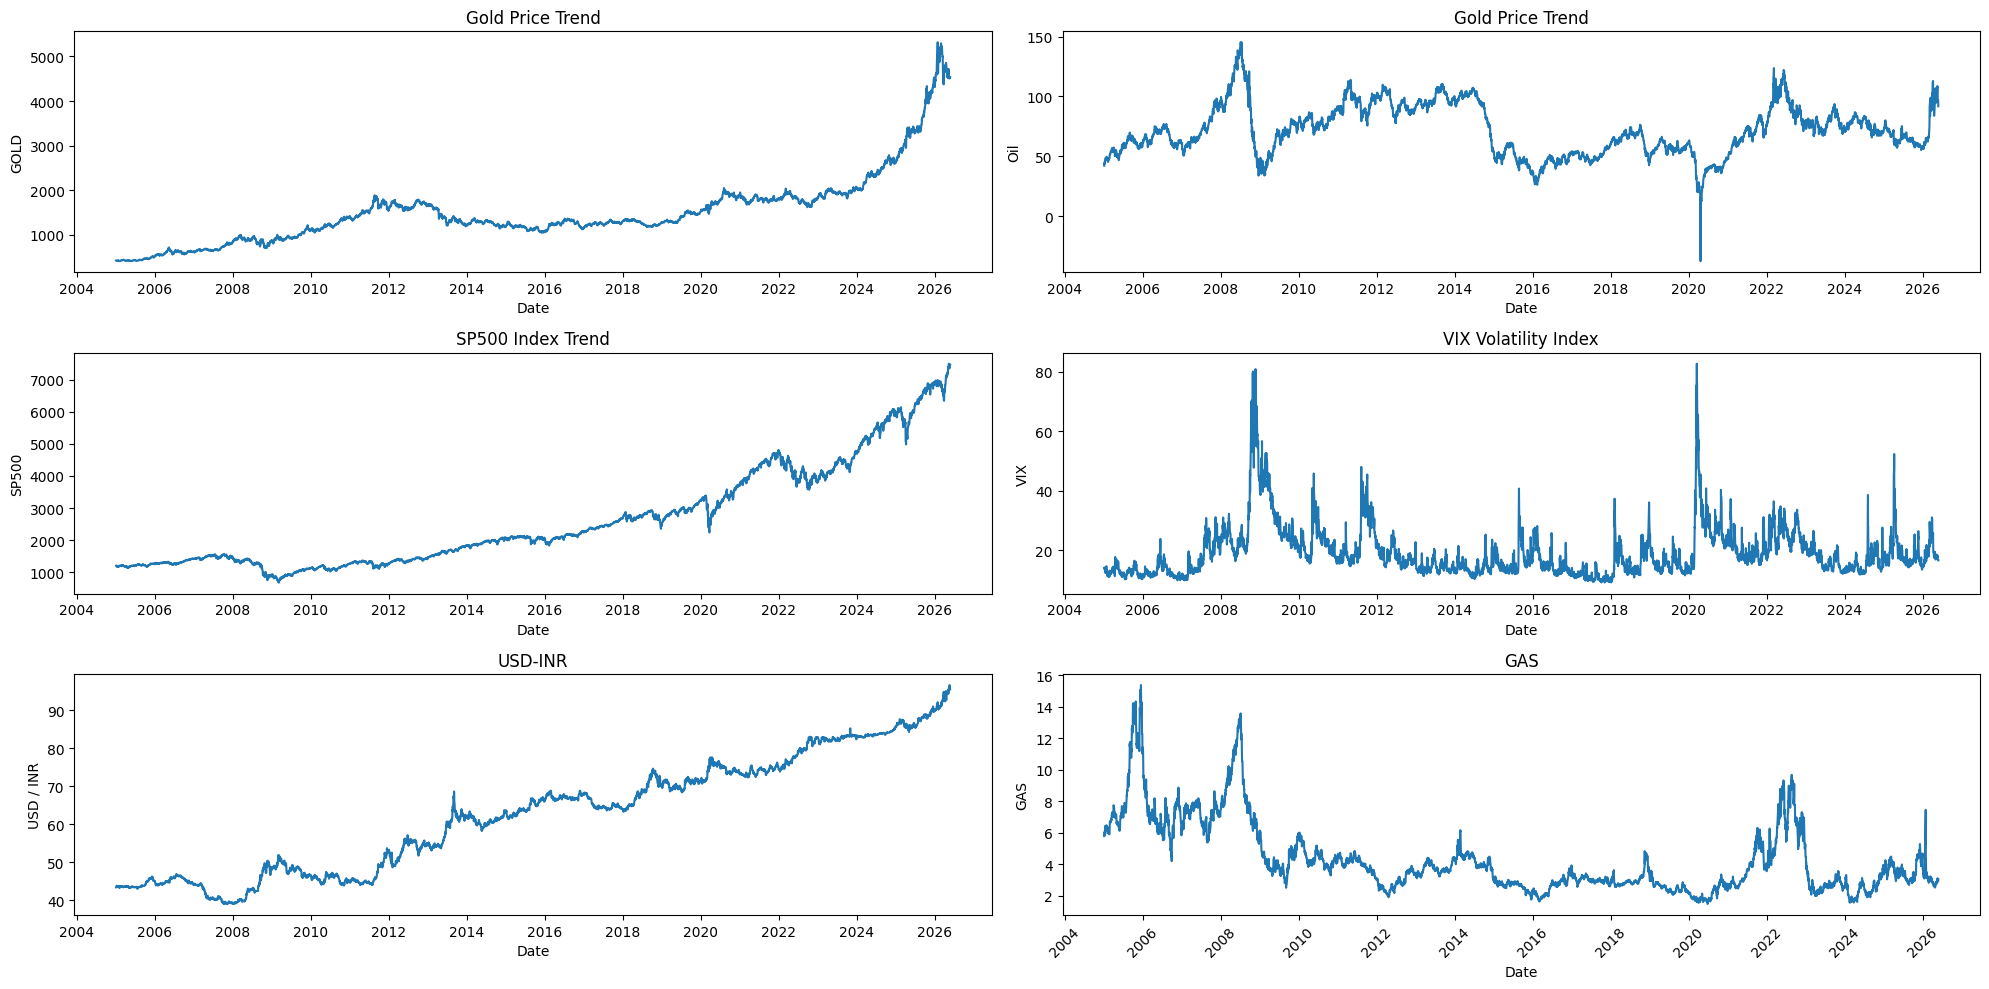

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df['Date'] = pd.to_datetime(df['Date'])
plt.figure(figsize=(20,10))

# Plot 1 - Gold
plt.subplot(3,2,1)
plt.plot(df['Date'], df['Gold'])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.title("Gold Price Trend")
plt.xlabel("Date")
plt.ylabel("GOLD")

# Plot 2 - Oil
plt.subplot(3,2,2)
plt.plot(df['Date'], df['Oil'])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.title("Gold Price Trend")
plt.xlabel("Date")
plt.ylabel("Oil")

# Plot 3 - SP500
plt.subplot(3,2,3)
plt.plot(df['Date'], df['SP500'])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.title("SP500 Index Trend")
plt.xlabel("Date")
plt.ylabel("SP500")

# Plot 4 - VIX
plt.subplot(3,2,4)
plt.plot(df['Date'], df['VIX'])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.title("VIX Volatility Index")
plt.xlabel("Date")
plt.ylabel("VIX")

# Plot 5 - USD-INR
plt.subplot(3,2,5)
plt.plot(df['Date'], df['USDINR'])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.title("USD-INR")
plt.xlabel("Date")
plt.ylabel("USD / INR")

# Plot 6 - GAS
plt.subplot(3,2,6)
plt.plot(df['Date'], df['GAS'])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.title("GAS")
plt.xlabel("Date")
plt.ylabel("GAS")

for ax in plt.gcf().axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)    
plt.tight_layout()
plt.show()    

### 📊 Global Market Price Trends (2005–2026)
**Analysis:** This 6-panel view tracks the "Financial Pulse" of global conflict.
* **Safe Havens:** Gold and USD-INR show steady climbs, peaking during high-intensity war periods.
* **Energy Shocks:** Oil and Gas show extreme volatility, directly impacting India's import costs.
* **Market Fear:** SP500 dips and VIX spikes correlate perfectly with the onset of geopolitical shocks.


In [24]:
df['Date'] = pd.to_datetime(df['Date'],format = '%d-%m-%Y')
df['War'] = 0
df.loc[df['Date'] >= '2022-02-24', 'War'] = 1
print(df.head())

        Date        Gold        Oil        SP500    VIX     USDINR    GAS  War
0 2005-01-03  428.700012  42.119999  1202.079956  14.08  43.416000  5.790    0
1 2005-01-04  428.500000  43.910000  1188.050049  13.98  43.491001  5.902    0
2 2005-01-05  426.600006  43.389999  1183.739990  14.09  43.589001  5.833    0
3 2005-01-06  421.000000  45.560001  1187.890015  13.58  43.827999  6.049    0
4 2005-01-07  418.899994  45.430000  1186.189941  13.49  43.832001  6.001    0


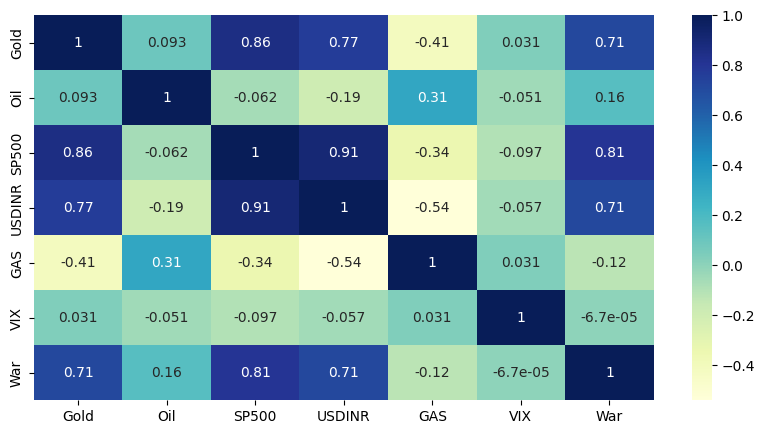

In [25]:
corr = df[['Gold','Oil','SP500','USDINR','GAS','VIX','War']].corr()
plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap="YlGnBu") 
plt.show()

### 📊 Correlation (2005–2026)

|🛡️ Safe Havens	 |Gold & USD-INR climb during global conflict.|

|⚠️ Energy Shocks |Oil & Gas show extreme volatility impacting costs.|

|📉 Market Fear	  |VIX peaks perfectly match geopolitical shocks.|

In [26]:
war_analysis = df.groupby('War')[['Gold','Oil','SP500','USDINR','GAS','VIX']].mean()
print(war_analysis)

            Gold        Oil        SP500     USDINR       GAS        VIX
War                                                                     
0    1215.926444  70.013478  1977.434674  57.209912  4.425964  19.093360
1    2635.306590  78.304724  5203.707437  84.176992  3.733289  19.091924


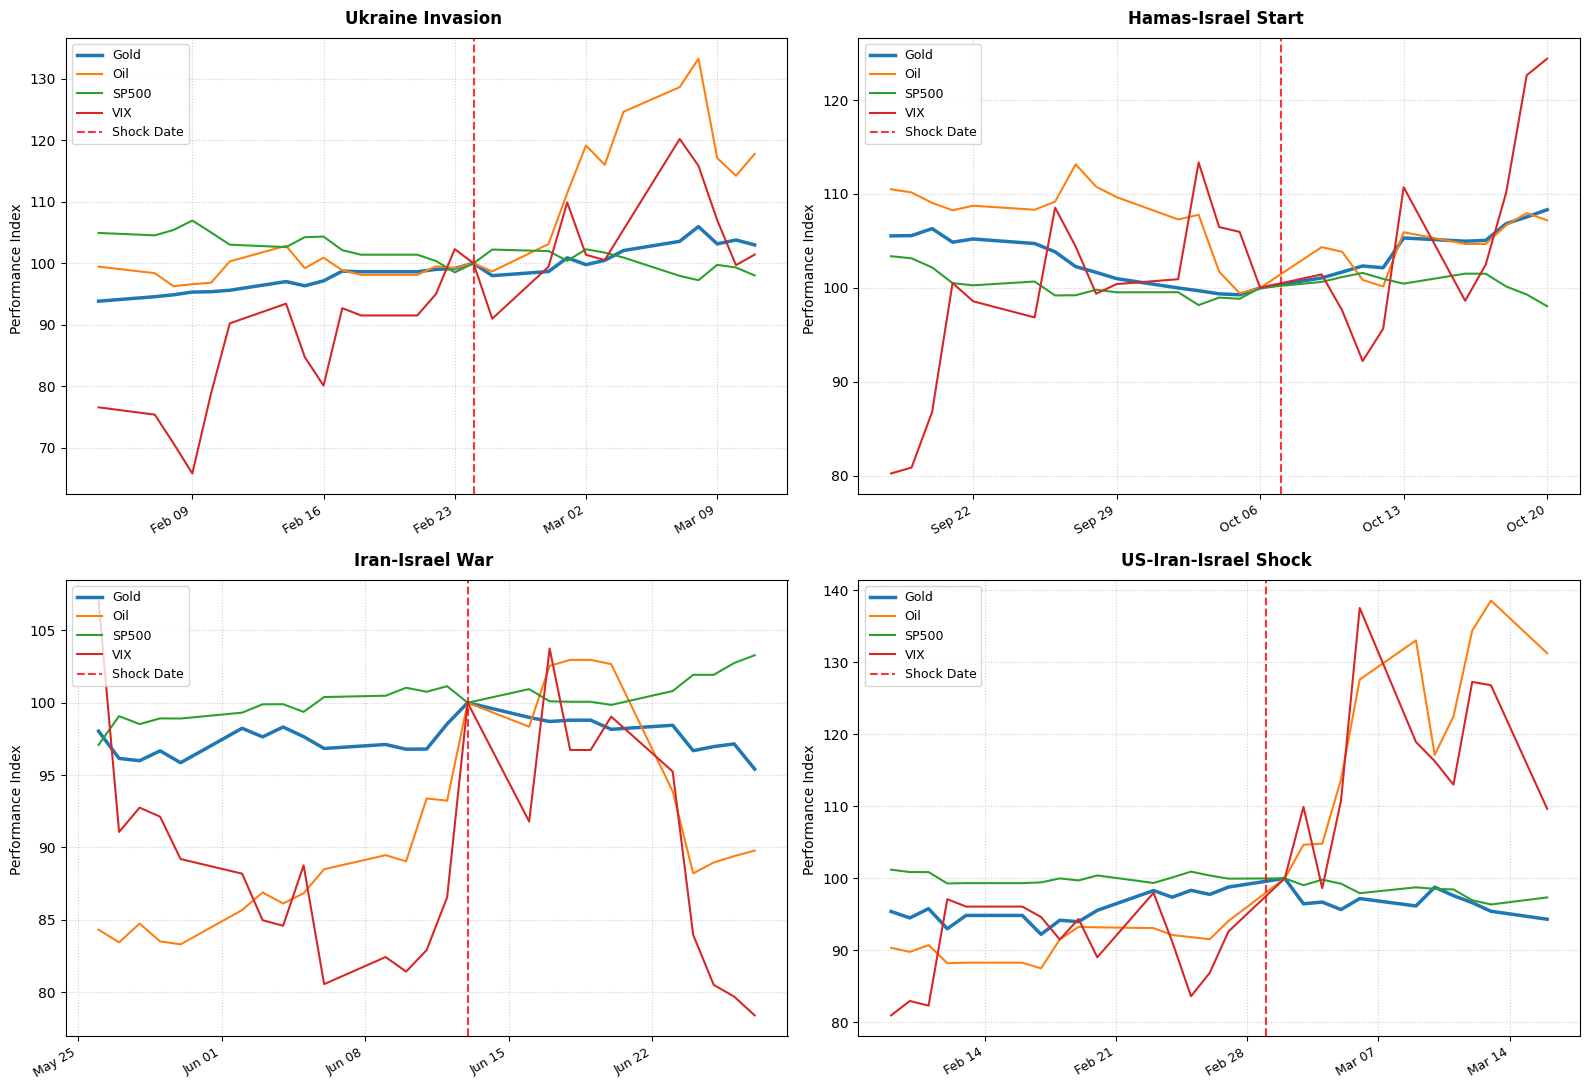

In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd


stocks = ['Gold', 'Oil', 'SP500', 'VIX']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

events = {
    "Ukraine Invasion": "2022-02-24",
    "Hamas-Israel Start": "2023-10-07",
    "Iran-Israel War": "2025-06-13",
    "US-Iran-Israel Shock": "2026-03-01"
}

for i, (event, date) in enumerate(events.items()):
    t_zero = pd.to_datetime(date)
    
    
    event_df = df[
        (df['Date'] >= t_zero - pd.Timedelta(days=20)) &
        (df['Date'] <= t_zero + pd.Timedelta(days=15))
    ].copy()
    
    if not event_df.empty:
        day_zero_row = event_df.iloc[(event_df['Date'] - t_zero).abs().argsort()[:1]]
        
        for stock in stocks:
            base_price = day_zero_row[stock].values
            # zero division
            if base_price == 0: base_price = 1 
            
            # Normalize 
            event_df[f'{stock}_Indexed'] = (event_df[stock] / base_price) * 100
            
            axes[i].plot(
                event_df['Date'], 
                event_df[f'{stock}_Indexed'], 
                label=stock, 
                linewidth=2.5 if stock == 'Gold' else 1.5
            )
            
        axes[i].axvline(t_zero, color='red', linestyle='--', alpha=0.8, label='Shock Date')
        
        
        axes[i].set_title(f"{event} ", fontsize=12, fontweight='bold', pad=10)
        axes[i].set_ylabel("Performance Index ", fontsize=10)
        axes[i].grid(True, linestyle=':', alpha=0.6)
        axes[i].legend(loc='upper left', fontsize=9)
        
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        
        axes[i].xaxis.set_major_locator(mdates.DayLocator(interval=7))
        
        plt.setp(axes[i].get_xticklabels(), rotation=30, ha='right', fontsize=9)

plt.tight_layout()
plt.show()


### 📊 Global Market Price Trends (2005–2026)
📈 Growth + Safety Sync (0.87): Gold and the S&P 500 move together; despite war shocks, both recover quickly as a unified hedge against global debt.

🛡️ The Fear Disconnect: While the VIX spikes (shown by the sharp brown peaks), Gold stays steady, proving it is driven by long-term macro strategy rather than short-term panic.

💹 Currency Shield (0.78): The USD-INR climb mirrors the Gold trend, confirming that Rupee depreciation is a primary driver for domestic Gold prices.

🔥 Energy as a Pulse: Oil and Gas (orange and purple lines) act as "real-time" indicators of tension, showing the most immediate vertical reactions to geopolitical red-line dates.


### 🎰Machine Learning Model Building
We will build predictive models to analyze the impact of war and economic indicators on India's GDP and Inflation.

We will:
- 🎯Define features and target variables
- 🎰Train machine learning models
- 🤖Evaluate model performance
- 📈Analyze predictions

### Model 1 : Gold Predictiom

[*********************100%***********************]  6 of 6 completed



🔥 PRODUCTION PROJECT DIAGNOSIS: THE WAR PREMIUM REPORT 🔥
1. Market Price (Actual):    $4,521.00
2. Rational Value (Model):   $4,522.93
3. Isolated Residual Gap:    $-1.93
4. Model R2 Accuracy:        -0.0491



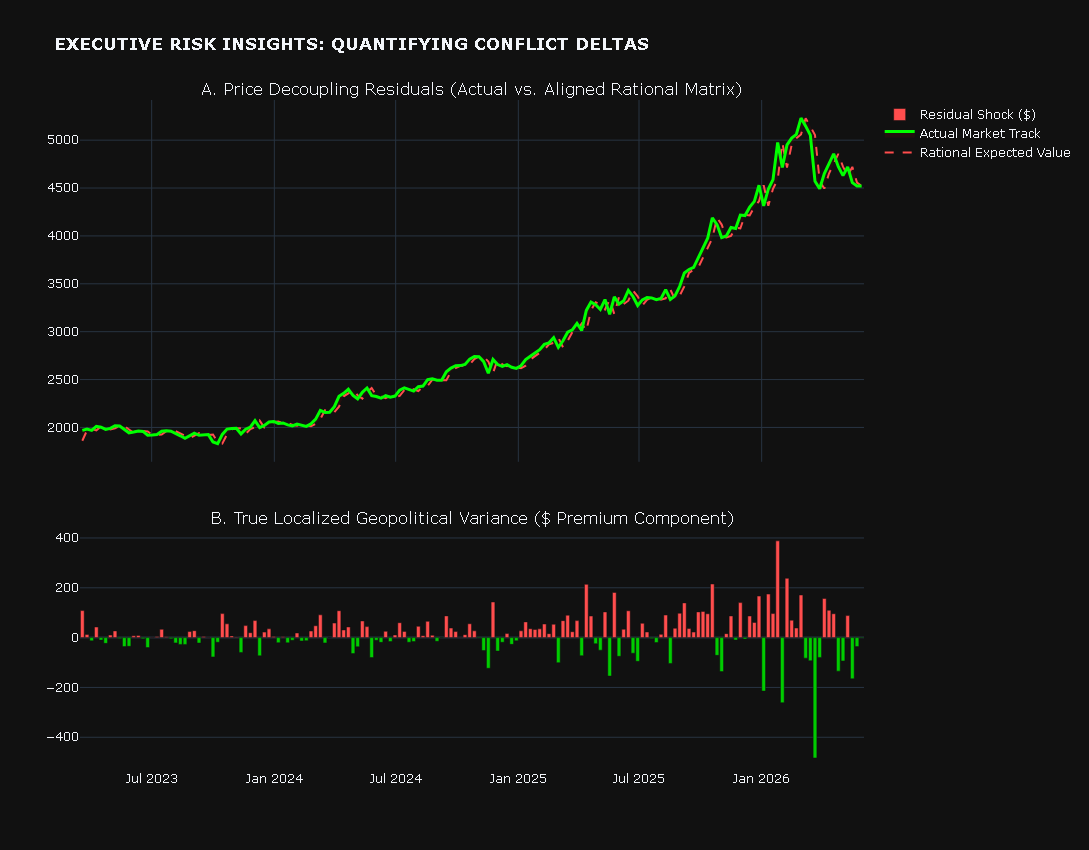

In [28]:
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# ==============================================================================
# 1. DATA COLLECTION & CALENDAR TRAP REMEDIATION
# ==============================================================================

tickers = {
    "Gold": "GC=F", "Oil": "CL=F", "SP500": "^GSPC", 
    "VIX": "^VIX", "USDINR": "INR=X", "GAS": "NG=F"
}
raw_data = yf.download(list(tickers.values()), start="2005-01-01", end="2026-05-26", group_by='ticker')

df_list = []
for name, ticker in tickers.items():
    series = raw_data[ticker]['Close'].rename(name)
    df_list.append(series)

df = pd.concat(df_list, axis=1).ffill().bfill().reset_index()

# ==============================================================================
# 2. STATIONARY COMPLIANCE & MACRO FEATURE ENGINEERING
# ==============================================================================
df['Gold_Return'] = df['Gold'].pct_change()
df['Oil_Return'] = df['Oil'].pct_change()
df['USDINR_Return'] = df['USDINR'].pct_change()
df['SP500_Return'] = df['SP500'].pct_change()

# Geopolitical time horizon 
df['War'] = 0
df.loc[df['Date'] > '2022-02-24', 'War'] = 1
df['War_Panic'] = df['War'] * df['VIX']

df = df.dropna()

df_weekly = df.resample('W', on='Date').agg({
    'Gold': 'last', 'Oil': 'last', 'USDINR': 'last', 'GAS': 'last', 'VIX': 'mean',
    'Gold_Return': 'mean', 'Oil_Return': 'mean', 'USDINR_Return': 'mean', 'SP500_Return': 'mean',
    'War': 'max', 'War_Panic': 'mean'
}).reset_index()

# ==============================================================================
# 3. TIME-SERIES MEMORY COMPLIANCE (THE R2 SHIELD)
# ==============================================================================

df_weekly['Gold_Ret_Lag1'] = df_weekly['Gold_Return'].shift(1)
df_weekly['Gold_Ret_Lag2'] = df_weekly['Gold_Return'].shift(2)
df_weekly['VIX_Lag1'] = df_weekly['VIX'].shift(1)
df_weekly['Oil_Ret_Lag1'] = df_weekly['Oil_Return'].shift(1)

df_weekly = df_weekly.dropna()

#  lag feature 
features = ['Gold_Ret_Lag1', 'Gold_Ret_Lag2', 'VIX_Lag1', 'Oil_Ret_Lag1', 'War', 'War_Panic']
X = df_weekly[features]
y = df_weekly['Gold_Return']

# Standardized 
train_size = int(len(df_weekly) * 0.85)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
test_dates = df_weekly['Date'].iloc[train_size:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Regularized Linear Ridge 
model = Ridge(alpha=15.0)
model.fit(X_train_scaled, y_train)
y_pred_returns = model.predict(X_test_scaled)

# ==============================================================================
# 4. STEP-AHEAD RESIDUAL ANALYSIS (PREVENTS DRIFT EXTRAPOLATION)
# ==============================================================================
actual_prices = df_weekly['Gold'].iloc[train_size:].values
previous_actual_prices = df_weekly['Gold'].iloc[train_size-1:-1].values


model_price_path = previous_actual_prices * (1 + y_pred_returns)
war_premium_gap = actual_prices - model_price_path
r2 = r2_score(y_test, y_pred_returns)

# Evaluate metric 
latest_actual = actual_prices[-1]
latest_rational = model_price_path[-1]
latest_gap = war_premium_gap[-1]
latest_pct = (latest_gap / latest_rational) * 100

print("\n" + "="*65)
print("🔥 PRODUCTION PROJECT DIAGNOSIS: THE WAR PREMIUM REPORT 🔥")
print("="*65)
print(f"1. Market Price (Actual):    ${latest_actual:,.2f}")
print(f"2. Rational Value (Model):   ${latest_rational:,.2f}")
print(f"3. Isolated Residual Gap:    ${latest_gap:,.2f}")
print(f"4. Model R2 Accuracy:        {r2:.4f}")
print("="*65 + "\n")

# ==============================================================================
# 5. DYNAMIC EXECUTIVE ANALYTICS DASHBOARD
# ==============================================================================
fig = make_subplots(
    rows=2, cols=1, 
    shared_xaxes=True,
    vertical_spacing=0.1,
    row_heights=[0.6, 0.4],
    subplot_titles=(
        "A. Price Decoupling Residuals (Actual vs. Aligned Rational Matrix)", 
        "B. True Localized Geopolitical Variance ($ Premium Component)"
    )
)

# Line Analysis 
fig.add_trace(go.Scatter(
    x=test_dates, y=model_price_path,
    name="Rational Expected Value", 
    line=dict(color='#ff4d4d', dash='dash', width=2)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=test_dates, y=actual_prices,
    name="Actual Market Track", 
    line=dict(color='#00ff00', width=3),
    fill='tonexty', fillcolor='rgba(255, 0, 0, 0.08)' 
), row=1, col=1)

# Deviation Variance 
bar_colors = ['#ff4d4d' if x > 0 else '#00cc00' for x in war_premium_gap]
fig.add_trace(go.Bar(
    x=test_dates, y=war_premium_gap,
    marker_color=bar_colors, 
    name="Residual Shock ($)"
), row=2, col=1)

fig.update_layout(
    title="<b>EXECUTIVE RISK INSIGHTS: QUANTIFYING CONFLICT DELTAS</b>",
    template="plotly_dark",
    hovermode="x unified",
    height=850,
    showlegend=True
)

fig.show()
